#**Importación de Librerías**

In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test)=keras.datasets.cifar10.load_data()

#Normalizar

X_train=X_train/255.0
X_test=X_test/255.0

#Red Neuronal Convolusional CNN (desde cero)

In [19]:
def modelo_cnn_base():
  model=keras.Sequential([
      layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
      layers.MaxPooling2D((2,2)),

      layers.Conv2D(64, (3,3), activation='relu'),
      layers.MaxPooling2D((2,2)),

      layers.Flatten(),
      layers.Dense(64,activation='relu'),
      layers.Dense(10, activation='softmax')
  ])
  model.compile(
      optimizer='adam',
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy']
  )
  return model

cnn_base=modelo_cnn_base()

history_base=cnn_base.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 83ms/step - accuracy: 0.4477 - loss: 1.5350 - val_accuracy: 0.5543 - val_loss: 1.2552
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 80ms/step - accuracy: 0.5875 - loss: 1.1715 - val_accuracy: 0.5999 - val_loss: 1.1393
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 80ms/step - accuracy: 0.6387 - loss: 1.0338 - val_accuracy: 0.6378 - val_loss: 1.0517
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 79ms/step - accuracy: 0.6667 - loss: 0.9558 - val_accuracy: 0.6480 - val_loss: 1.0344
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 80ms/step - accuracy: 0.6910 - loss: 0.8900 - val_accuracy: 0.6619 - val_loss: 0.9683
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.7117 - loss: 0.8337 - val_accuracy: 0.6756 - val_loss: 0.9431
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.7256 - loss: 0.7890 - val_accuracy: 0.6780 - val_loss: 0.9314
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 80ms/step - accuracy: 0.7396 - loss: 0.7506 - 

#Transfe Learning

In [20]:
base_model=keras.applications.MobileNetV2(
    input_shape=(32,32,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable=False

model_tl=keras.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_tl=model_tl.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)

/tmp/ipykernel_27051/3126069319.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model=keras.applications.MobileNetV2(


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 75ms/step - accuracy: 0.2863 - loss: 1.9798 - val_accuracy: 0.3102 - val_loss: 1.8990
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - accuracy: 0.3213 - loss: 1.8713 - val_accuracy: 0.3230 - val_loss: 1.8723
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 74ms/step - accuracy: 0.3333 - loss: 1.8421 - val_accuracy: 0.3286 - val_loss: 1.8513
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step - accuracy: 0.3416 - loss: 1.8189 - val_accuracy: 0.3350 - val_loss: 1.8378
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - accuracy: 0.3461 - loss: 1.7997 - val_accuracy: 0.3371 - val_loss: 1.8276
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 74ms/step - accuracy: 0.3535 - loss: 1.7837 - val_accuracy: 0.3415 - val_loss: 1.8177
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 76ms/step - accuracy: 0.3580 - loss: 1.7707 - val_accuracy: 0.3430 - val_loss: 1.8160
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 74ms/step - accuracy: 0.3620 - loss: 1.7593 - 

#Graficación

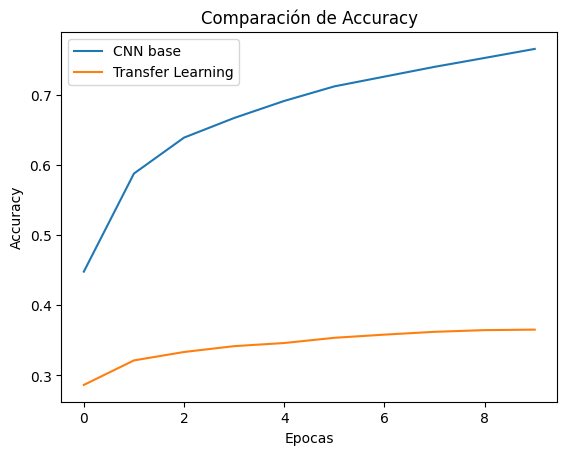

In [21]:
plt.plot(history_base.history['accuracy'], label='CNN base')
plt.plot(history_tl.history['accuracy'], label='Transfer Learning')

plt.title("Comparación de Accuracy")
plt.xlabel("Epocas")
plt.ylabel("Accuracy")
plt.legend()
plt.show()